exploring problems

In [13]:
import pandas as pd
import scipy.stats as stats
import ast

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)
df.head()

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0
1,8,High pass,['Accurate'],Abdullah Ibrahim Otayf,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,4.487814,High pass,258612106,35,53,75.0,19.0
2,1,Air duel,"['Won', 'Accurate']",Ilya Kutepov,"Russia - Saudi Arabia, 5 - 0",Duel,Russia,1H,5.937411,Air duel,258612077,25,81,37.0,83.0
3,1,Air duel,"['Lost', 'Not accurate']",Yasir Gharsan Al Shahrani,"Russia - Saudi Arabia, 5 - 0",Duel,Saudi Arabia,1H,6.406961,Air duel,258612112,75,19,63.0,17.0
4,8,Simple pass,['Accurate'],Salman Mohammed Al Faraj,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,8.562167,Simple pass,258612110,63,17,71.0,15.0


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

- #passes -> winning
- cant do correlation because winning is categorical
- so t test or anova
- [(win/draw) loss] for t test
- ANOVA win/loss/draw

In [15]:
df["eventName"].unique()

array(['Pass', 'Duel', 'Free Kick', 'Foul', 'Others on the ball', 'Shot',
       'Save attempt', 'Offside', 'Goalkeeper leaving line'], dtype=object)

In [16]:
df["pass"] = (df["eventName"] == "Pass").astype(int)
df["shot"] = (df["eventName"] == "Shot").astype(int)
df.head()

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0
1,8,High pass,['Accurate'],Abdullah Ibrahim Otayf,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,4.487814,High pass,258612106,35,53,75.0,19.0,1,0
2,1,Air duel,"['Won', 'Accurate']",Ilya Kutepov,"Russia - Saudi Arabia, 5 - 0",Duel,Russia,1H,5.937411,Air duel,258612077,25,81,37.0,83.0,0,0
3,1,Air duel,"['Lost', 'Not accurate']",Yasir Gharsan Al Shahrani,"Russia - Saudi Arabia, 5 - 0",Duel,Saudi Arabia,1H,6.406961,Air duel,258612112,75,19,63.0,17.0,0,0
4,8,Simple pass,['Accurate'],Salman Mohammed Al Faraj,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,8.562167,Simple pass,258612110,63,17,71.0,15.0,1,0


In [17]:
df.groupby("matchId").first().reset_index()["matchId"]

0        Argentina - Croatia, 0 - 3
1        Argentina - Iceland, 1 - 1
2           Australia - Peru, 0 - 2
3          Belgium - England, 2 - 0
4            Belgium - Japan, 3 - 2
                  ...              
59         Tunisia - England, 1 - 2
60          Uruguay - France, 0 - 2
61        Uruguay - Portugal, 2 - 1
62          Uruguay - Russia, 3 - 0
63    Uruguay - Saudi Arabia, 1 - 0
Name: matchId, Length: 64, dtype: object

In [18]:
def get_outcome(row):
    teamId = row["teamId"]
    match = row["matchId"]
    teams, scores = match.split(",")
    tm1, tm2 = teams.split(" - ")
    score1, score2 = scores.split(" - ")
    score2 = score2.split("(")[0]
    score1 = int(score1)
    score2 = int(score2)
    if teamId == tm1:
        if score1 > score2:
            return "win"
        elif score1 < score2:
            return "loss"
        else:
            return "draw"
    else: #tm2 == teamId
        if score1 > score2:
            return "loss"
        elif score1 < score2:
            return "win"
        else:
            return "draw"

df["outcome"] = df.apply(get_outcome, axis=1)

In [19]:
df["outcome"].value_counts()

outcome
win     40517
loss    38867
draw    22375
Name: count, dtype: int64

In [20]:
df.groupby("matchId", "teamId").agg({"outcome": "first"}).value_counts()

ValueError: No axis named teamId for object type DataFrame

In [21]:
group_df = df.groupby(["matchId", "teamId"]).agg(
    shots=("shot", "sum"),
    passes=("pass", "sum"),
    outcome=("outcome", "first")
).reset_index()
group_df

,matchId,teamId,shots,passes,outcome
0,"Argentina - Croatia, 0 - 3",Argentina,10,476,loss
1,"Argentina - Croatia, 0 - 3",Croatia,13,334,win
2,"Argentina - Iceland, 1 - 1",Argentina,22,744,draw
3,"Argentina - Iceland, 1 - 1",Iceland,8,183,draw
4,"Australia - Peru, 0 - 2",Australia,11,512,loss
...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,238,win
124,"Uruguay - Russia, 3 - 0",Russia,3,327,loss
125,"Uruguay - Russia, 3 - 0",Uruguay,12,466,win
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,553,loss


In [22]:
cats = df["outcome"].unique()
cats

array(['loss', 'win', 'draw'], dtype=object)

In [23]:
pass_samples = [df.loc[df["outcome"] == c, "passes"] for c in cats]

KeyError: 'passes'

In [24]:
cats = group_df ["outcome"].unique()
cats
pass_samples = [group_df.loc[group_df["outcome"] == c, "passes"] for c in cats]
f, p = stats.f_oneway(*pass_samples)

alpha = 0.05
dfb = len(pass_samples) - 1
dfw = sum([len(s) for s in pass_samples]) - len(pass_samples) #pass_samples is a lsit of lists [[, [], []]

crit = stats.f.ppf(1 - alpha, dfb, dfw)
print(f"F: {f:.4f}, critical value: {crit:.4f}, p-value: {p:.4f}")

F: 2.2838, critical value: 3.0687, p-value: 0.1061


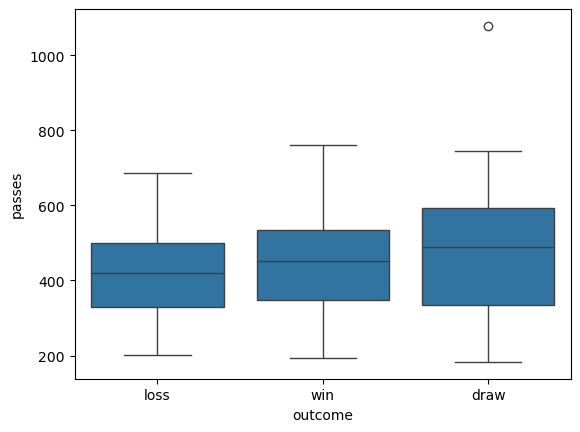

In [25]:
box = sns.boxplot(data=group_df, x="outcome", y="passes")

In [26]:
p_losers = group_df.loc[group_df["outcome"] == "loss", "passes"]
p_n_losers = group_df.loc[group_df["outcome"] != "loss", "passes"]

t,p = stats.ttest_ind(p_losers, p_n_losers)
deg_f = len(p_losers) + len(p_n_losers) - 2
ct = stats.t.ppf(1 - alpha/2, deg_f)
print(f"T= {t:.4f}, critical= {ct:.4f}, p= {p:.4f}")

T= -1.6951, critical= 1.9790, p= 0.0925
